
# Text Cleaning Pipeline
### NLP preprocessing implemented
- Case folding
- Contraction expansion
- Special-character removal
- Stopword removal
- Hashtag and mention removal
- Extra-space removal
- Before/after comparison
- Word counts
- Frequency analysis
- Text-size reduction



## 0. Setup and Imports

Run this cell first. It installs/imports only the libraries needed by the notebook.


In [16]:

# Install required packages if they are missing
%pip install -q pandas matplotlib seaborn nltk

import re
import string
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords

# Download the English stopword list if needed
nltk.download("stopwords", quiet=True)

STOPWORDS = set(stopwords.words("english"))

print(f"Loaded {len(STOPWORDS)} English stopwords.")


Loaded 198 English stopwords.


## 1. Reusable Text-Cleaning Functions

In [17]:

# Common contractions required by the task sheet, plus additional common forms.
CONTRACTIONS = {
    "aren't": "are not",
    "can't": "cannot",
    "couldn't": "could not",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hasn't": "has not",
    "haven't": "have not",
    "he's": "he is",
    "i'd": "i would",
    "i'll": "i will",
    "i'm": "i am",
    "i've": "i have",
    "isn't": "is not",
    "it's": "it is",
    "let's": "let us",
    "mightn't": "might not",
    "mustn't": "must not",
    "shan't": "shall not",
    "she's": "she is",
    "shouldn't": "should not",
    "that's": "that is",
    "there's": "there is",
    "they're": "they are",
    "they've": "they have",
    "wasn't": "was not",
    "we're": "we are",
    "weren't": "were not",
    "what's": "what is",
    "where's": "where is",
    "who's": "who is",
    "won't": "will not",
    "wouldn't": "would not",
    "you're": "you are",
    "you've": "you have",
}

def expand_contractions(text):
    """Expand contractions without changing other words."""
    text = str(text)
    # Longer contractions first to avoid partial replacements.
    for contraction in sorted(CONTRACTIONS, key=len, reverse=True):
        replacement = CONTRACTIONS[contraction]
        text = re.sub(
            rf"\b{re.escape(contraction)}\b",
            replacement,
            text,
            flags=re.IGNORECASE
        )
    return text

def remove_mentions_hashtags(text):
    """Remove @mentions and #hashtags completely."""
    text = re.sub(r"(?<!\w)[@#][A-Za-z0-9_]+", " ", str(text))
    return text

def remove_special_characters(text):
    """Keep letters/numbers/spaces; remove punctuation and symbols."""
    return re.sub(r"[^a-zA-Z0-9\s]", " ", str(text))

def clean_text(text, remove_social_tags=False):
    """
    Full preprocessing pipeline:
    1. case folding
    2. contraction expansion
    3. optional mention/hashtag removal
    4. special-character removal
    5. stopword removal
    6. extra-space removal
    """
    text = str(text)

    # Case folding first, as required.
    text = text.lower()

    # Expand contractions before punctuation is removed.
    text = expand_contractions(text)

    if remove_social_tags:
        text = remove_mentions_hashtags(text)

    text = remove_special_characters(text)

    # Tokenize using whitespace after punctuation/symbol cleanup.
    tokens = text.split()

    # Remove English stopwords.
    tokens = [word for word in tokens if word not in STOPWORDS]

    # Join once to guarantee no unnecessary spaces.
    return " ".join(tokens)

def word_count(text):
    """Count whitespace-separated words in the supplied text."""
    return len(str(text).split())

def cleaned_word_count(text, remove_social_tags=False):
    return word_count(clean_text(text, remove_social_tags=remove_social_tags))

def reduction_percentage(before, after):
    if before == 0:
        return 0.0
    return ((before - after) / before) * 100

print("Cleaning functions are ready.")


Cleaning functions are ready.



# Practical Task 1 — Text Cleaning Pipeline

The task sheet gives this sample input:

> "I'm really HAPPY about this product!!! It's amazing & I don't think I've ever used something this good. @product #awesome"

The required output includes the original and cleaned text side by side, plus word counts before and after preprocessing. fileciteturn0file0L8-L24


In [18]:

sample_review = (
    "I'm really HAPPY about this product!!! It's amazing & I don't "
    "think I've ever used something this good. @product #awesome"
)

cleaned_review = clean_text(sample_review)

task1_result = pd.DataFrame({
    "Original Text": [sample_review],
    "Cleaned Text": [cleaned_review],
    "Words Before": [word_count(sample_review)],
    "Words After": [word_count(cleaned_review)]
})

display(task1_result)

print("\nTask 1 cleaned text:")
print(cleaned_review)


,Original Text,Cleaned Text,Words Before,Words After
0,I'm really HAPPY about this product!!! It's am...,really happy product amazing think ever used s...,20,11



Task 1 cleaned text:
really happy product amazing think ever used something good product awesome


In [19]:

# Task 1 detailed transformation checks
print("Contraction expansion examples:")
for example in ["don't", "can't", "I'm", "it's", "won't"]:
    print(f"{example:>7} -> {expand_contractions(example)}")

before = word_count(sample_review)
after = word_count(cleaned_review)

print(f"\nWords before preprocessing : {before}")
print(f"Words after preprocessing  : {after}")
print(f"Words removed              : {before - after}")


Contraction expansion examples:
  don't -> do not
  can't -> cannot
    I'm -> i am
   it's -> it is
  won't -> will not

Words before preprocessing : 20
Words after preprocessing  : 11
Words removed              : 9



# Practical Task 2 — Social Media Text Cleaning

The task requires case folding, special-character removal, stopword removal, contraction expansion, extra-space removal, and explicit removal of hashtags and mentions. fileciteturn0file0L30-L42


In [20]:

social_comments = [
    "OMG!!! I can't believe this 😍 @user #Amazing",
    "This movie wasn't good... I don't recommend it!!!",
    "I'm LOVING this product!!! It's sooo good 😍"
]

task2_df = pd.DataFrame({"Original Comment": social_comments})

task2_df["Cleaned Comment"] = task2_df["Original Comment"].apply(
    lambda x: clean_text(x, remove_social_tags=True)
)
task2_df["Words Before"] = task2_df["Original Comment"].apply(word_count)
task2_df["Words After"] = task2_df["Cleaned Comment"].apply(word_count)

display(task2_df)

print("\nTask 2 comparison:")
for _, row in task2_df.iterrows():
    print("-" * 80)
    print("BEFORE :", row["Original Comment"])
    print("AFTER  :", row["Cleaned Comment"])


,Original Comment,Cleaned Comment,Words Before,Words After
0,OMG!!! I can't believe this 😍 @user #Amazing,omg cannot believe,8,3
1,This movie wasn't good... I don't recommend it!!!,movie good recommend,8,3
2,I'm LOVING this product!!! It's sooo good 😍,loving product sooo good,8,4



Task 2 comparison:
--------------------------------------------------------------------------------
BEFORE : OMG!!! I can't believe this 😍 @user #Amazing
AFTER  : omg cannot believe
--------------------------------------------------------------------------------
BEFORE : This movie wasn't good... I don't recommend it!!!
AFTER  : movie good recommend
--------------------------------------------------------------------------------
BEFORE : I'm LOVING this product!!! It's sooo good 😍
AFTER  : loving product sooo good



# Practical Task 3 — Customer Review Preprocessing

The task asks for **100 customer reviews**, a new `cleaned_review` column, and comparison of average words before/after cleaning. It also asks for the **10 most frequent words** in the cleaned reviews. fileciteturn0file0L43-L54

Because the supplied task sheet does not contain the actual 100-review dataset, the next cell creates a **100-row built-in demonstration dataset** from realistic review templates. Replace `reviews_100` with your actual dataset when available.


In [21]:

# Built-in 100-review demonstration dataset.
# Replace this list with your actual 100 reviews if your instructor provides a dataset.

review_templates = [
    "I'm really happy with this product! The quality is excellent and delivery was fast.",
    "This product is amazing, and I don't think I have seen such good quality before.",
    "I wasn't happy with the packaging, but the product itself works very well.",
    "The service was quick and friendly. I'm impressed with the support team!",
    "It's a useful product for students, and the price is reasonable.",
    "I can't recommend this enough. The performance is excellent and reliable.",
    "The item arrived late, but it was packed safely and works perfectly.",
    "This was a great purchase. I love the design and the simple features.",
    "I don't like the material because it feels cheap and weak.",
    "The product is good, but the instructions aren't clear enough.",
    "Amazing customer service! They solved my problem quickly.",
    "I'm very satisfied with the quality, performance, and overall experience.",
    "The delivery was fast, but the box was damaged when it arrived.",
    "I won't buy this again because the battery life is poor.",
    "It's comfortable, affordable, and easy to use every day.",
    "The software is simple, fast, and useful for my work.",
    "I had a great experience and would definitely recommend this product.",
    "The product wasn't as described, so I returned it.",
    "Excellent quality! The product looks premium and works smoothly.",
    "I'm happy with my purchase and the seller was very helpful."
]

reviews_100 = [
    review_templates[i % len(review_templates)] + f" Review number {i+1}."
    for i in range(100)
]

reviews_df = pd.DataFrame({"review": reviews_100})

# Required cleaned_review column.
reviews_df["cleaned_review"] = reviews_df["review"].apply(clean_text)

# Before/after word counts.
reviews_df["words_before"] = reviews_df["review"].apply(word_count)
reviews_df["words_after"] = reviews_df["cleaned_review"].apply(word_count)

print("Number of reviews:", len(reviews_df))
display(reviews_df.head(10))


Number of reviews: 100


,review,cleaned_review,words_before,words_after
0,I'm really happy with this product! The qualit...,really happy product quality excellent deliver...,17,10
1,"This product is amazing, and I don't think I h...",product amazing think seen good quality review...,18,9
2,"I wasn't happy with the packaging, but the pro...",happy packaging product works well review numb...,16,8
3,The service was quick and friendly. I'm impres...,service quick friendly impressed support team ...,15,9
4,"It's a useful product for students, and the pr...",useful product students price reasonable revie...,14,8
5,I can't recommend this enough. The performance...,cannot recommend enough performance excellent ...,14,9
6,"The item arrived late, but it was packed safel...",item arrived late packed safely works perfectl...,15,10
7,This was a great purchase. I love the design a...,great purchase love design simple features rev...,16,9
8,I don't like the material because it feels che...,like material feels cheap weak review number 9,14,8
9,"The product is good, but the instructions aren...",product good instructions clear enough review ...,13,8


,Metric,Value
0,Number of reviews,100.00
1,Average words before cleaning,14.10
2,Average words after cleaning,8.45
3,Average words removed,5.65
4,Average percentage reduction,40.07


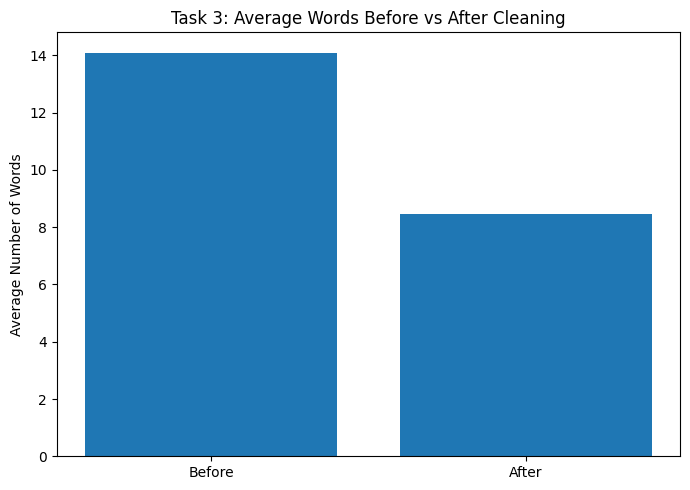

In [22]:

# Average number of words before and after cleaning
avg_before = reviews_df["words_before"].mean()
avg_after = reviews_df["words_after"].mean()

task3_summary = pd.DataFrame({
    "Metric": [
        "Number of reviews",
        "Average words before cleaning",
        "Average words after cleaning",
        "Average words removed",
        "Average percentage reduction"
    ],
    "Value": [
        len(reviews_df),
        round(avg_before, 2),
        round(avg_after, 2),
        round(avg_before - avg_after, 2),
        round(reduction_percentage(avg_before, avg_after), 2)
    ]
})

display(task3_summary)

# Plot average word counts.
plt.figure(figsize=(7, 5))
plt.bar(["Before", "After"], [avg_before, avg_after])
plt.ylabel("Average Number of Words")
plt.title("Task 3: Average Words Before vs After Cleaning")
plt.tight_layout()
plt.show()


Top 10 most frequent words in cleaned reviews:


,Word,Frequency
0,review,100
1,number,100
2,product,40
3,quality,20
4,happy,15
5,excellent,15
6,fast,15
7,works,15
8,delivery,10
9,amazing,10


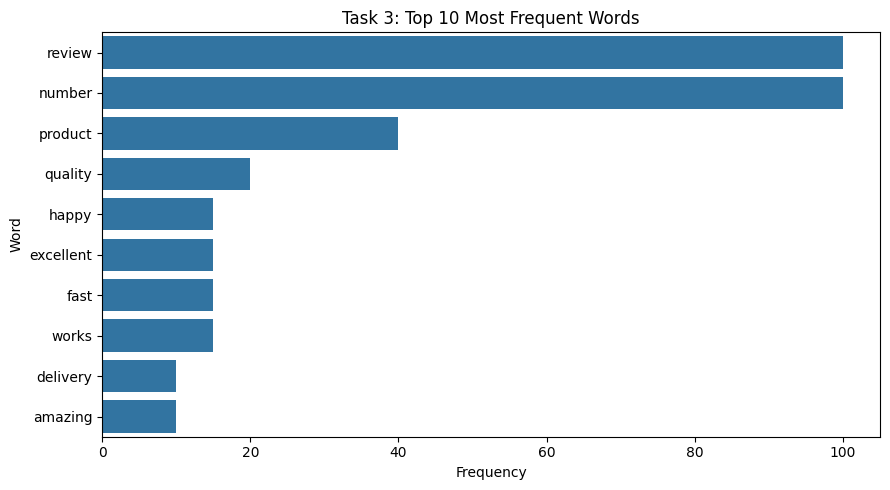

In [23]:

# Top 10 most frequent words in cleaned reviews
all_cleaned_review_words = " ".join(reviews_df["cleaned_review"]).split()
review_word_frequency = Counter(all_cleaned_review_words)

top10_review_words = pd.DataFrame(
    review_word_frequency.most_common(10),
    columns=["Word", "Frequency"]
)

print("Top 10 most frequent words in cleaned reviews:")
display(top10_review_words)

plt.figure(figsize=(9, 5))
sns.barplot(data=top10_review_words, x="Frequency", y="Word")
plt.title("Task 3: Top 10 Most Frequent Words")
plt.tight_layout()
plt.show()



## Optional: Use Your Own 100-Review CSV

If your teacher gives a CSV, it should contain a review/text column. Run the next cell and change `CSV_PATH`.

Expected output columns after processing:
- `review`
- `cleaned_review`
- `words_before`
- `words_after`


In [24]:

# OPTIONAL CELL — change this path to your CSV.
# Example:
# CSV_PATH = "customer_reviews.csv"

CSV_PATH = None

if CSV_PATH:
    uploaded_reviews = pd.read_csv(CSV_PATH)

    # Automatically find a likely text column.
    possible_columns = [
        c for c in uploaded_reviews.columns
        if c.lower() in {"review", "reviews", "text", "comment", "comments"}
    ]

    if not possible_columns:
        raise ValueError(
            "Could not find a review/text column. Rename the text column to 'review'."
        )

    text_column = possible_columns[0]
    uploaded_reviews["review"] = uploaded_reviews[text_column].astype(str)
    uploaded_reviews["cleaned_review"] = uploaded_reviews["review"].apply(clean_text)
    uploaded_reviews["words_before"] = uploaded_reviews["review"].apply(word_count)
    uploaded_reviews["words_after"] = uploaded_reviews["cleaned_review"].apply(word_count)

    display(uploaded_reviews.head())
    print("Number of rows:", len(uploaded_reviews))
else:
    print("CSV_PATH is None. Using the built-in 100-review demonstration dataset above.")


CSV_PATH is None. Using the built-in 100-review demonstration dataset above.



# Practical Task 4 — News Article Text Cleaning

The task asks for **20 news articles** and requires:
- case folding
- contraction handling
- special-character removal
- stopword removal
- total words before preprocessing
- total words after preprocessing
- 10 most frequent words
- most frequent stopwords
- text-size reduction fileciteturn0file0L60-L70

The following cell provides 20 built-in demonstration article texts because the task sheet itself does not contain the 20 full articles.


In [25]:

news_articles = [
    "The government announced a new technology program on Monday, saying it will support digital education and improve access to online learning.",
    "A major technology company launched a new artificial intelligence platform that can help businesses analyze data and automate routine tasks.",
    "Scientists reported that a new research project could improve renewable energy systems and reduce the cost of clean electricity.",
    "The city opened a new public transport station, and officials said the project will make daily travel faster and safer for residents.",
    "A university team developed an innovative software tool that helps students organize study materials and track academic progress.",
    "The health department introduced a public awareness campaign focused on healthy habits, regular exercise, and better access to community services.",
    "Local businesses welcomed the new economic policy, saying that lower costs and improved infrastructure could support future growth.",
    "Researchers are studying climate patterns to understand how changing weather conditions may affect agriculture and water resources.",
    "The education department announced new training programs for teachers and said schools will receive additional digital learning resources.",
    "A startup raised new investment to develop software for small businesses, with the company planning to expand its services across the country.",
    "The transport authority said construction of the new highway is progressing well, although some areas will require additional safety work.",
    "Experts discussed how artificial intelligence is changing workplaces and explained that employees will need new technical and communication skills.",
    "The national museum opened a new exhibition featuring historical objects, photographs, and stories from communities across the region.",
    "A new environmental project aims to restore forests and protect wildlife, while local groups will help monitor the progress of the program.",
    "The sports organization announced a new youth program that will provide training opportunities and encourage students to participate in team activities.",
    "A financial report showed that consumer spending increased during the quarter, while analysts said market conditions remain uncertain.",
    "The weather department warned that heavy rainfall may affect several districts and advised residents to follow local safety instructions.",
    "A research team published a study on language technology and said new models could improve communication tools for regional languages.",
    "The company said it has expanded its customer support service and will introduce faster response systems for online requests.",
    "Officials said the new community project is designed to improve public facilities and create more opportunities for local residents."
]

news_df = pd.DataFrame({
    "article_id": range(1, 21),
    "article": news_articles
})

news_df["cleaned_article"] = news_df["article"].apply(clean_text)
news_df["words_before"] = news_df["article"].apply(word_count)
news_df["words_after"] = news_df["cleaned_article"].apply(word_count)

print("Number of news articles:", len(news_df))
display(news_df.head())


Number of news articles: 20


,article_id,article,cleaned_article,words_before,words_after
0,1,The government announced a new technology prog...,government announced new technology program mo...,21,14
1,2,A major technology company launched a new arti...,major technology company launched new artifici...,20,15
2,3,Scientists reported that a new research projec...,scientists reported new research project could...,19,14
3,4,The city opened a new public transport station...,city opened new public transport station offic...,22,15
4,5,A university team developed an innovative soft...,university team developed innovative software ...,18,14


In [26]:

# 4.1 Total words before and after preprocessing
total_before = int(news_df["words_before"].sum())
total_after = int(news_df["words_after"].sum())
words_removed = total_before - total_after

print("Task 4 Results")
print("=" * 50)
print(f"Total words before preprocessing : {total_before}")
print(f"Total words after preprocessing  : {total_after}")
print(f"Total words removed              : {words_removed}")
print(f"Text size reduction              : {reduction_percentage(total_before, total_after):.2f}%")


Task 4 Results
Total words before preprocessing : 390
Total words after preprocessing  : 279
Total words removed              : 111
Text size reduction              : 28.46%


Top 10 most frequent words in cleaned news articles:


,Word,Frequency
0,new,14
1,said,7
2,improve,4
3,project,4
4,local,4
5,announced,3
6,technology,3
7,program,3
8,support,3
9,company,3


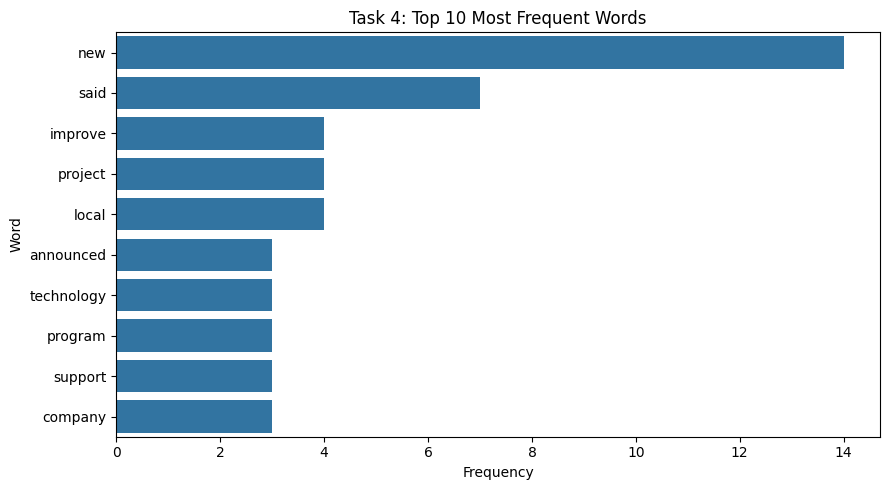

In [27]:

# 4.2 Top 10 words in cleaned news articles
all_cleaned_news_words = " ".join(news_df["cleaned_article"]).split()
news_word_frequency = Counter(all_cleaned_news_words)

top10_news_words = pd.DataFrame(
    news_word_frequency.most_common(10),
    columns=["Word", "Frequency"]
)

print("Top 10 most frequent words in cleaned news articles:")
display(top10_news_words)

plt.figure(figsize=(9, 5))
sns.barplot(data=top10_news_words, x="Frequency", y="Word")
plt.title("Task 4: Top 10 Most Frequent Words")
plt.tight_layout()
plt.show()


Top 10 most frequent stopwords in the original news articles:


,Stopword,Frequency
0,the,20
1,and,19
2,a,14
3,to,9
4,will,8
5,that,8
6,for,6
7,on,3
8,of,3
9,is,3


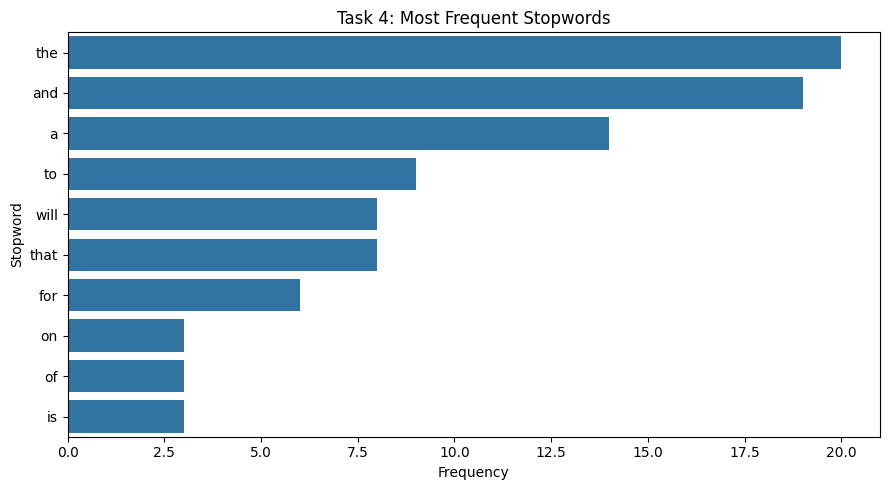

In [28]:

# 4.3 Most frequent stopwords BEFORE stopword removal
# This directly measures which stopwords occurred most frequently in the original articles.

original_news_words = re.findall(r"\b[a-zA-Z]+\b", " ".join(news_df["article"]).lower())
stopword_counts = Counter(word for word in original_news_words if word in STOPWORDS)

top10_stopwords = pd.DataFrame(
    stopword_counts.most_common(10),
    columns=["Stopword", "Frequency"]
)

print("Top 10 most frequent stopwords in the original news articles:")
display(top10_stopwords)

plt.figure(figsize=(9, 5))
sns.barplot(data=top10_stopwords, x="Frequency", y="Stopword")
plt.title("Task 4: Most Frequent Stopwords")
plt.tight_layout()
plt.show()


,article_id,words_before,words_after,words_removed,reduction_%
0,1,21,14,7,33.33
1,2,20,15,5,25.00
2,3,19,14,5,26.32
3,4,22,15,7,31.82
4,5,18,14,4,22.22
5,6,20,15,5,25.00
6,7,18,15,3,16.67
7,8,17,13,4,23.53
8,9,18,14,4,22.22
9,10,22,14,8,36.36


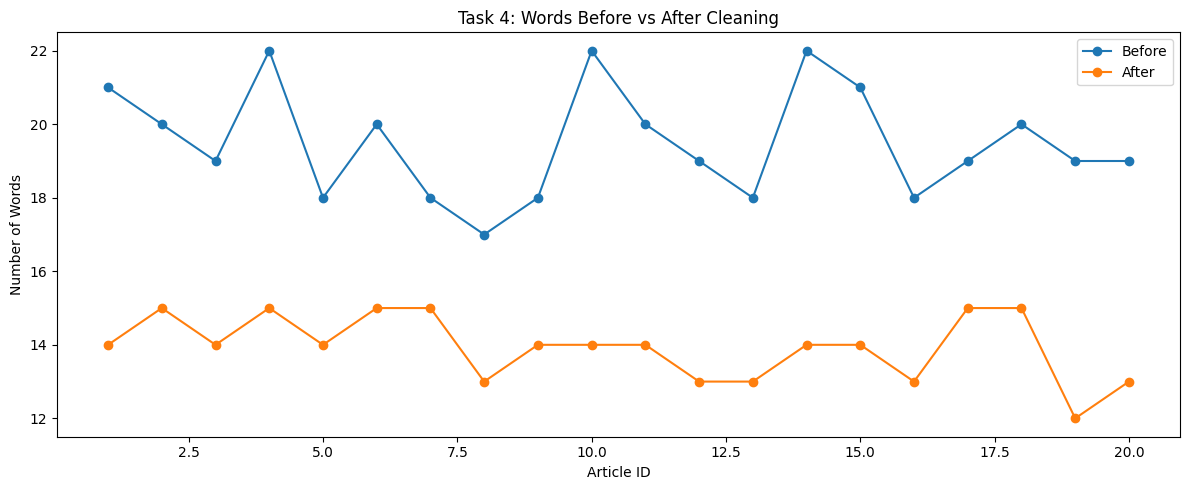

In [29]:

# 4.4 Per-article comparison
news_comparison = news_df[
    ["article_id", "words_before", "words_after"]
].copy()

news_comparison["words_removed"] = (
    news_comparison["words_before"] - news_comparison["words_after"]
)

news_comparison["reduction_%"] = (
    news_comparison.apply(
        lambda row: reduction_percentage(
            row["words_before"], row["words_after"]
        ),
        axis=1
    ).round(2)
)

display(news_comparison)

plt.figure(figsize=(12, 5))
plt.plot(
    news_comparison["article_id"],
    news_comparison["words_before"],
    marker="o",
    label="Before"
)
plt.plot(
    news_comparison["article_id"],
    news_comparison["words_after"],
    marker="o",
    label="After"
)
plt.xlabel("Article ID")
plt.ylabel("Number of Words")
plt.title("Task 4: Words Before vs After Cleaning")
plt.legend()
plt.tight_layout()
plt.show()



# Final Combined Results

This final section prints a concise submission-ready summary for all four tasks.


In [30]:

print("=" * 70)
print("TEXT CLEANING PIPELINE — FINAL SUMMARY")
print("=" * 70)

print("\nTASK 1 — TEXT CLEANING PIPELINE")
print(f"Words before : {word_count(sample_review)}")
print(f"Words after  : {word_count(cleaned_review)}")
print(f"Cleaned text : {cleaned_review}")

print("\nTASK 2 — SOCIAL MEDIA TEXT CLEANING")
print(f"Number of comments processed : {len(task2_df)}")
print(f"Total words before           : {task2_df['Words Before'].sum()}")
print(f"Total words after            : {task2_df['Words After'].sum()}")

print("\nTASK 3 — CUSTOMER REVIEWS")
print(f"Reviews processed            : {len(reviews_df)}")
print(f"Average words before         : {avg_before:.2f}")
print(f"Average words after          : {avg_after:.2f}")
print(f"Average reduction            : {reduction_percentage(avg_before, avg_after):.2f}%")
print("Top 10 words:")
print(", ".join(top10_review_words["Word"].tolist()))

print("\nTASK 4 — NEWS ARTICLES")
print(f"Articles processed           : {len(news_df)}")
print(f"Total words before           : {total_before}")
print(f"Total words after            : {total_after}")
print(f"Words removed                : {words_removed}")
print(f"Text size reduction          : {reduction_percentage(total_before, total_after):.2f}%")
print("Top 10 cleaned words:")
print(", ".join(top10_news_words["Word"].tolist()))
print("Top 10 stopwords:")
print(", ".join(top10_stopwords["Stopword"].tolist()))

print("\nAll four practical tasks completed.")


TEXT CLEANING PIPELINE — FINAL SUMMARY

TASK 1 — TEXT CLEANING PIPELINE
Words before : 20
Words after  : 11
Cleaned text : really happy product amazing think ever used something good product awesome

TASK 2 — SOCIAL MEDIA TEXT CLEANING
Number of comments processed : 3
Total words before           : 24
Total words after            : 10

TASK 3 — CUSTOMER REVIEWS
Reviews processed            : 100
Average words before         : 14.10
Average words after          : 8.45
Average reduction            : 40.07%
Top 10 words:
review, number, product, quality, happy, excellent, fast, works, delivery, amazing

TASK 4 — NEWS ARTICLES
Articles processed           : 20
Total words before           : 390
Total words after            : 279
Words removed                : 111
Text size reduction          : 28.46%
Top 10 cleaned words:
new, said, improve, project, local, announced, technology, program, support, company
Top 10 stopwords:
the, and, a, to, will, that, for, on, of, is

All four practical ta